# Marginalization analysis

Analyze ChromBPNet marginalization results across cell types.
Adapted from `stimulated_sc-islets/manuscripts/ChromBetaNet/scratch/2025_06_22/2_marginalization_analysis.ipynb`

# Set-up

In [1]:
import glob
import numpy as np
import pandas as pd

import logomaker as lm

from tangermeme.io import read_meme

from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
import os

# Paths
dataset = "sc-islet-differentiation_10X-Multiome"
base_dir = f"/cellar/users/aklie/data/datasets/{dataset}"
results_dir = f"{base_dir}/results/3_single_task_models"

path_motif_file = f"{results_dir}/motifs/gimme_cluster/meme/combined.meme"
path_motif_annotation = f"{results_dir}/motifs/gimme_cluster/tfs_initial.txt"

path_out = f"{results_dir}/motifs/gimme_cluster/marginalization/gimme_average"
os.makedirs(path_out, exist_ok=True)

# Load cell type colors
cell_type_meta = pd.read_csv(f"{base_dir}/config/cell_type_metadata.tsv", sep="\t")
color_dict = dict(zip(cell_type_meta["cell_type"], cell_type_meta["color"]))
celltype_order = cell_type_meta["cell_type"].tolist()

# Load motifs and marginalization data

In [3]:
# Load motif names
motif_dict = read_meme(path_motif_file)
motifs = list(motif_dict.items())
names = np.array([m[0] for m in motifs], dtype="U")

# Load motif annotations
initial_motifs = pd.read_csv(path_motif_annotation, sep="\t", header=None)
initial_motifs.columns = ["cluster_name", "top_tomtom_annotation", "evalue"]
annotation_dict = initial_motifs.set_index("cluster_name")["top_tomtom_annotation"].to_dict()

print(f"{len(names)} motifs loaded")

70 motifs loaded


In [4]:
# Load marginalization count data across all completed cell types
path_counts = sorted(glob.glob(f"{results_dir}/*/fold_0/chrombpnet/0.5/marginalization/gimme_average/marginalization_data.counts.npz"))
print(f"Found {len(path_counts)} cell types with marginalization data")

dfs = []
for path in path_counts:
    celltype = path.split("/")[-6]
    counts_ = np.load(path)
    c_before = counts_['c_before'].squeeze()
    c_after = counts_['c_after'].squeeze()
    c_diff = c_after - c_before
    c_diff_mean = np.mean(c_diff, axis=-1)

    df = pd.DataFrame({
        "name": names,
        "c_diff_mean": c_diff_mean,
        "celltype": celltype,
    })
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df = df.merge(initial_motifs, left_on="name", right_on="cluster_name", how="left")
print(f"{len(df)} rows: {df['celltype'].nunique()} cell types x {df['name'].nunique()} motifs")
df.head()

Found 22 cell types with marginalization data


1540 rows: 22 cell types x 70 motifs


,name,c_diff_mean,celltype,cluster_name,top_tomtom_annotation,evalue
0,Average_131,0.839957,DE,Average_131,ZN143_MOUSE.H11MO.0.A,7.288700e-24
1,Average_168,0.540866,DE,Average_168,REST_MA0138.2,2.329340e-22
2,Average_234,0.023679,DE,Average_234,NFIC_HUMAN.H11MO.0.A,2.117190e-05
3,Average_436,0.170536,DE,Average_436,Foxg1.mouse_forkhead_1,3.195520e-02
4,Average_501,0.698369,DE,Average_501,SIX1_HUMAN.H11MO.0.A,7.965210e-09


# Clustermap of marginalization effects

In [5]:
# Pivot into motifs x cell types matrix
matrix = df.pivot(index="name", columns="celltype", values="c_diff_mean")

# Reorder columns by cell type order (only those present)
col_order = [ct for ct in celltype_order if ct in matrix.columns]
matrix = matrix[col_order]

# Z-score across cell types
matrix_z = (matrix - matrix.mean(axis=1).values[:, np.newaxis]) / matrix.std(axis=1).values[:, np.newaxis]
matrix_z = matrix_z.fillna(0)

print(f"Matrix shape: {matrix_z.shape}")

Matrix shape: (70, 22)


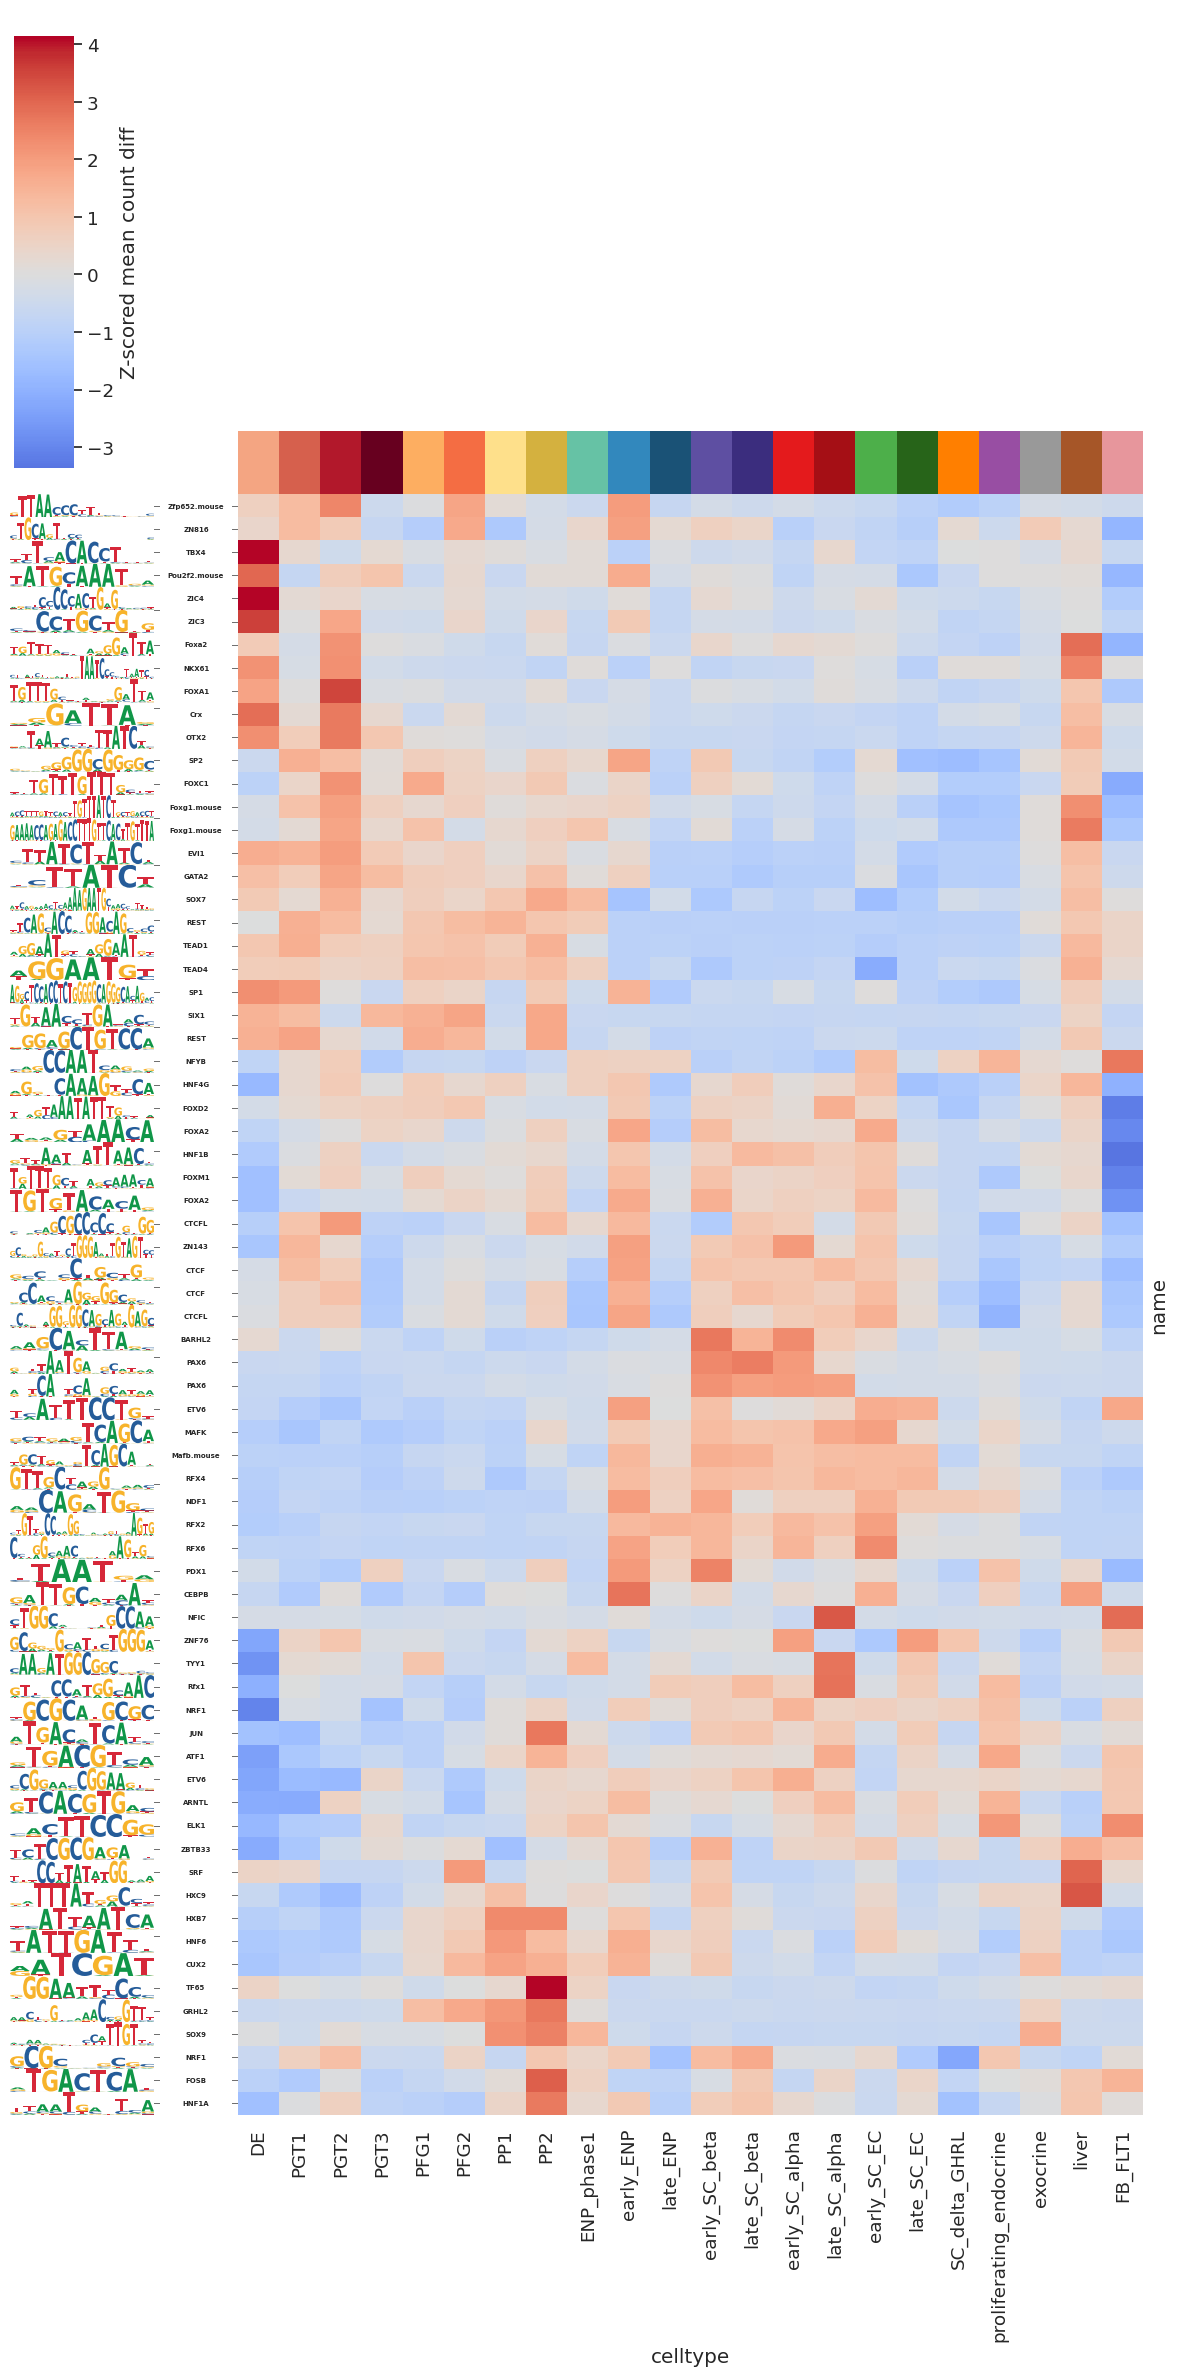

In [6]:
LOGO_ALPHABET = 'ACGT'
LOGO_COLORS = {"A": '#109648', "C": '#255C99', "G": '#F7B32B', "T": '#D62839'}

# Color columns by cell type
col_colors = [color_dict.get(ct, '#999999') for ct in matrix_z.columns]

sns.set_theme(style="white", font_scale=1.2)
g = sns.clustermap(
    matrix_z,
    cmap="coolwarm",
    center=0,
    figsize=(12, 24),
    row_cluster=True,
    col_cluster=False,
    col_colors=col_colors,
    cbar_kws={"label": "Z-scored mean count diff"},
    yticklabels=False,
)

# Get the reordered row indices from the dendrogram
row_order = g.dendrogram_row.reordered_ind
ordered_motif_names = [matrix_z.index[i] for i in row_order]

# Add logo + annotation to the left of the heatmap
heatmap_ax = g.ax_heatmap
heatmap_pos = heatmap_ax.get_position()

# Create a new axes for logos to the left of the heatmap
logo_width = 0.12
annot_width = 0.06
logo_ax_pos = [heatmap_pos.x0 - logo_width - annot_width - 0.01, heatmap_pos.y0, logo_width, heatmap_pos.height]
annot_ax_pos = [heatmap_pos.x0 - annot_width - 0.005, heatmap_pos.y0, annot_width, heatmap_pos.height]

n_rows = len(ordered_motif_names)
row_height = heatmap_pos.height / n_rows

for i, motif_name in enumerate(ordered_motif_names):
    annotation = annotation_dict.get(motif_name, motif_name).split('_')[0]
    
    # Logo
    logo_ax = g.fig.add_axes([
        logo_ax_pos[0],
        logo_ax_pos[1] + (n_rows - 1 - i) * row_height,
        logo_ax_pos[2],
        row_height,
    ])
    ppm = motif_dict[motif_name].numpy().T
    lm_df = lm.transform_matrix(
        df=pd.DataFrame(ppm, columns=list(LOGO_ALPHABET)),
        from_type='probability',
        to_type='information',
    )
    lm.Logo(lm_df, ax=logo_ax, color_scheme=LOGO_COLORS, fade_below=0.1)
    logo_ax.set_xticks([])
    logo_ax.set_yticks([])
    for spine in logo_ax.spines.values():
        spine.set_visible(False)

    # Annotation text
    annot_ax = g.fig.add_axes([
        annot_ax_pos[0],
        annot_ax_pos[1] + (n_rows - 1 - i) * row_height,
        annot_ax_pos[2],
        row_height,
    ])
    annot_ax.text(0.5, 0.5, annotation, ha='center', va='center', fontsize=5, fontweight='bold')
    annot_ax.set_xlim(0, 1)
    annot_ax.set_xticks([])
    annot_ax.set_yticks([])
    for spine in annot_ax.spines.values():
        spine.set_visible(False)

plt.savefig(f"{path_out}/marginalization_clustermap.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Differential motif activity across cell types

In [7]:
# ANOVA for each motif across cell types
anova_results = []
tukey_results = []

for motif_name in df["name"].unique():
    motif_data = df[df["name"] == motif_name]
    groups = [group["c_diff_mean"].values for _, group in motif_data.groupby("celltype")]

    # Need at least 2 groups with data
    if len(groups) < 2:
        continue

    result = f_oneway(*groups)
    anova_results.append({
        "motif": motif_name,
        "annotation": annotation_dict.get(motif_name, motif_name),
        "F": result.statistic,
        "pvalue": result.pvalue,
    })

    if result.pvalue < 0.1:
        tukey = pairwise_tukeyhsd(
            motif_data["c_diff_mean"],
            motif_data["celltype"],
            alpha=0.05,
        )
        for row in tukey.summary().data[1:]:
            tukey_results.append({
                "motif": motif_name,
                "group1": row[0],
                "group2": row[1],
                "meandiff": row[2],
                "p_adj": row[3],
                "lower": row[4],
                "upper": row[5],
                "reject": row[6],
            })

anova_df = pd.DataFrame(anova_results).sort_values("pvalue")
tukey_df = pd.DataFrame(tukey_results)

significant_motifs = anova_df[anova_df["pvalue"] < 0.05]
print(f"{len(significant_motifs)} motifs with significant ANOVA (p < 0.05)")
significant_motifs.head(20)

/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:567: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
/tmp/ipykernel_2223231/533222616.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  result = f_oneway(*groups)
/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:567: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
/tmp/ipykernel_2223231/533222616.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  result = f_oneway(*groups)
/cellar/users/aklie/opt/

0 motifs with significant ANOVA (p < 0.05)


/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:567: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
/tmp/ipykernel_2223231/533222616.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  result = f_oneway(*groups)
/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:567: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
/tmp/ipykernel_2223231/533222616.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  result = f_oneway(*groups)
/cellar/users/aklie/opt/

,motif,annotation,F,pvalue


# Profile plots for significant motifs

In [8]:
# Load profile data
path_profiles = sorted(glob.glob(f"{results_dir}/*/fold_0/chrombpnet/0.5/marginalization/gimme_average/marginalization_data.profiles.npz"))

profiles = {}
for path in path_profiles:
    celltype = path.split("/")[-6]
    profile_ = np.load(path)
    p_before = profile_['p_before'].squeeze()
    p_after = profile_['p_after'].squeeze()
    p_diff = p_after - p_before
    profiles[celltype] = {name: p_diff[i] for i, name in enumerate(names)}

print(f"Loaded profiles for {len(profiles)} cell types")

Loaded profiles for 22 cell types


In [9]:
# Order cell types
ordered_models = [ct for ct in celltype_order if ct in profiles]

# Use top significant motifs (up to 20)
top_motifs = significant_motifs.head(20)
n_sig = len(top_motifs)
n_models = len(ordered_models)

if n_sig > 0 and n_models > 0:
    fig, axes = plt.subplots(nrows=n_sig, ncols=n_models, figsize=(n_models * 0.8, n_sig * 0.5), dpi=300)
    if n_sig == 1:
        axes = axes[np.newaxis, :]

    for i in range(n_sig):
        sig_motif = top_motifs["motif"].values[i]
        annotation = annotation_dict.get(sig_motif, sig_motif).split('_')[0]

        # Get profiles and find global y range
        sig_profiles = {ct: profiles[ct][sig_motif][400:600] for ct in ordered_models}
        ymin = min(p.min() for p in sig_profiles.values())
        ymax = max(p.max() for p in sig_profiles.values())
        ymin = -(abs(ymin) * 1.05) if ymin < 0 else ymin * 0.95
        ymax = ymax * 1.05

        for j, ct in enumerate(ordered_models):
            ax = axes[i, j]
            color = color_dict.get(ct, '#999999')
            ax.fill_between(range(200), sig_profiles[ct], alpha=0.7, color=color, linewidth=0)
            ax.axhline(y=0, color='black', linewidth=0.3)
            ax.set_ylim(ymin, ymax)
            ax.set_xlim(0, 200)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

            if i == 0:
                ax.set_title(ct, fontsize=6, rotation=45, ha='left')
            if j == 0:
                ax.set_ylabel(annotation, fontsize=6, rotation=0, ha='right', va='center')

    plt.tight_layout()
    plt.savefig(f"{path_out}/marginalization_profiles_top{n_sig}.pdf", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Not enough data for profile plots")

Not enough data for profile plots


# Save results

In [10]:
# Save tables
anova_df.to_csv(f"{path_out}/anova_celltypes.csv", index=False)
if len(tukey_df) > 0:
    tukey_df.to_csv(f"{path_out}/tukey_celltypes.csv", index=False)
significant_motifs.to_csv(f"{path_out}/significant_motifs.csv", index=False)
matrix.to_csv(f"{path_out}/marginalization_matrix.csv")
matrix_z.to_csv(f"{path_out}/marginalization_matrix_zscore.csv")

print(f"Saved to {path_out}")

Saved to /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/3_single_task_models/motifs/analysis


# DONE!

# TF expression × motif activity overlay

For each motif, the TomTom annotation tells us a TF family — but multiple family members could be binding.
By showing motif activity (marginalization c_diff) alongside expression of all candidate family members,
we can infer which TF is likely responsible in each cell type.

Inspired by Metzl-Raz et al. (cardiac organoid, Fig 3C-D) and Nair et al. (fibroblast reprogramming, ChromVAR + expression).

In [11]:
# Load pseudobulk TF expression
pseudobulk = pd.read_csv(f"{base_dir}/results/2_process_data/pseudobulk_tf_expression.csv", index_col=0)

# Reorder to match cell type order
ct_in_expr = [ct for ct in celltype_order if ct in pseudobulk.index]
pseudobulk = pseudobulk.reindex(ct_in_expr)

# Define TF families — motif annotation root → candidate gene symbols
tf_families = {
    "FOX": ["FOXA1", "FOXA2", "FOXC1", "FOXD2", "FOXG1", "FOXM1", "FOXO1", "FOXP1"],
    "HNF4": ["HNF4A", "HNF4G"],
    "HNF1": ["HNF1A", "HNF1B"],
    "HNF6": ["ONECUT1", "ONECUT2"],
    "RFX": ["RFX2", "RFX4", "RFX5", "RFX6"],
    "GATA": ["GATA4", "GATA6"],
    "PAX": ["PAX4", "PAX6"],
    "NKX": ["NKX2-2", "NKX6-1"],
    "ETS": ["ETV6", "ELK1", "ETS1"],
    "MAF": ["MAFA", "MAFB"],
    "TEAD": ["TEAD1", "TEAD4"],
    "SOX": ["SOX9", "SOX17"],
    "SP": ["SP1", "SP2"],
    "JUN": ["JUN", "JUNB", "JUND"],
    "FOS": ["FOS", "FOSB"],
}

# Map each motif to its TF family
def get_family(annotation):
    root = annotation.split("_")[0].split(".")[0].upper()
    for family, members in tf_families.items():
        if family.upper() in root or root in [m.upper().split("-")[0] for m in members]:
            return family
    return None

motif_to_family = {}
for motif_name in names:
    ann = annotation_dict.get(motif_name, "")
    family = get_family(ann)
    if family:
        motif_to_family[motif_name] = family

print(f"Motifs with TF family mapping: {len(motif_to_family)} / {len(names)}")
for motif, family in sorted(motif_to_family.items(), key=lambda x: x[1]):
    ann = annotation_dict.get(motif, motif).split("_")[0]
    members = tf_families[family]
    avail = [m for m in members if m in pseudobulk.columns]
    print(f"  {ann:15s} ({motif:40s}) -> {family:6s} family: {avail}")

Motifs with TF family mapping: 34 / 70
  ETV6            (Average_635                             ) -> ETS    family: ['ETV6', 'ELK1', 'ETS1']
  ETV6            (Average_644                             ) -> ETS    family: ['ETV6', 'ELK1', 'ETS1']
  ELK1            (Average_645                             ) -> ETS    family: ['ETV6', 'ELK1', 'ETS1']
  FOSB            (Average_657                             ) -> FOS    family: ['FOS', 'FOSB']
  Foxg1.mouse     (Average_436                             ) -> FOX    family: ['FOXA1', 'FOXA2', 'FOXC1', 'FOXD2', 'FOXG1', 'FOXM1']
  FOXD2           (Average_566                             ) -> FOX    family: ['FOXA1', 'FOXA2', 'FOXC1', 'FOXD2', 'FOXG1', 'FOXM1']
  FOXM1           (Average_608                             ) -> FOX    family: ['FOXA1', 'FOXA2', 'FOXC1', 'FOXD2', 'FOXG1', 'FOXM1']
  FOXA2           (Average_625                             ) -> FOX    family: ['FOXA1', 'FOXA2', 'FOXC1', 'FOXD2', 'FOXG1', 'FOXM1']
  FOXA1           

In [12]:
# For each ambiguous motif family, create a side-by-side figure:
# Left: motif marginalization effect (bar per cell type)
# Right: expression of each family member (lines per cell type)

ambiguous_motifs = {m: f for m, f in motif_to_family.items() if len(tf_families[f]) > 1}
os.makedirs(f"{path_out}/tf_resolution", exist_ok=True)

for motif_name, family in ambiguous_motifs.items():
    annotation = annotation_dict.get(motif_name, motif_name).split("_")[0]
    members = [m for m in tf_families[family] if m in pseudobulk.columns]
    
    if len(members) < 2:
        continue
    
    # Get marginalization effect
    marg_vals = matrix.loc[motif_name, col_order] if motif_name in matrix.index else None
    if marg_vals is None:
        continue
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.5]})
    
    # Left: marginalization barplot
    colors = [color_dict.get(ct, "#999999") for ct in col_order]
    axes[0].barh(range(len(col_order)), marg_vals.values, color=colors)
    axes[0].set_yticks(range(len(col_order)))
    axes[0].set_yticklabels(col_order, fontsize=7)
    axes[0].set_xlabel("Mean count diff (marginalization)")
    axes[0].set_title(f"{annotation} motif activity")
    axes[0].invert_yaxis()
    
    # Right: expression heatmap of family members
    expr_data = pseudobulk.loc[col_order, members]
    # Z-score per gene for visualization
    expr_z = (expr_data - expr_data.mean()) / expr_data.std()
    expr_z = expr_z.fillna(0)
    
    im = axes[1].imshow(expr_z.values, aspect="auto", cmap="viridis", interpolation="nearest")
    axes[1].set_xticks(range(len(members)))
    axes[1].set_xticklabels(members, fontsize=9, rotation=45, ha="right")
    axes[1].set_yticks(range(len(col_order)))
    axes[1].set_yticklabels(col_order, fontsize=7)
    axes[1].set_title(f"{family} family expression (z-scored)")
    plt.colorbar(im, ax=axes[1], shrink=0.6, label="Z-score")
    
    plt.suptitle(f"{annotation} ({motif_name}) — {family} family resolution", fontsize=10)
    plt.tight_layout()
    plt.savefig(f"{path_out}/tf_resolution/{motif_name}_{family}_resolution.pdf", dpi=150, bbox_inches="tight")
    plt.close(fig)

print(f"Saved {len(ambiguous_motifs)} TF resolution figures to {path_out}/tf_resolution/")

Saved 34 TF resolution figures to /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/3_single_task_models/motifs/analysis/tf_resolution/


In [13]:
# Summary: side-by-side heatmap of motif activity (marginalization) vs best TF expression
# For each motif with a family mapping, pick the family member whose expression pattern
# best correlates with the marginalization effect across cell types

from scipy.stats import pearsonr

resolution_results = []

for motif_name in names:
    annotation = annotation_dict.get(motif_name, motif_name).split("_")[0]
    family = motif_to_family.get(motif_name)
    
    if motif_name not in matrix.index:
        continue
    
    marg = matrix.loc[motif_name, col_order].values
    
    if family and family in tf_families:
        members = [m for m in tf_families[family] if m in pseudobulk.columns]
        if members:
            best_gene = None
            best_corr = -1
            for gene in members:
                expr = pseudobulk.loc[col_order, gene].values
                if np.std(expr) > 0 and np.std(marg) > 0:
                    r, _ = pearsonr(marg, expr)
                    if r > best_corr:
                        best_corr = r
                        best_gene = gene
            
            resolution_results.append({
                "motif": motif_name,
                "annotation": annotation,
                "family": family,
                "best_gene": best_gene,
                "correlation": best_corr,
                "all_members": ", ".join(members),
            })

res_df = pd.DataFrame(resolution_results).sort_values("correlation", ascending=False)
res_df.to_csv(f"{path_out}/tf_resolution_summary.csv", index=False)

print(f"TF resolution for {len(res_df)} motifs:")
print(f"  Mean correlation (motif activity vs best TF expression): {res_df['correlation'].mean():.3f}")
print(f"  Motifs with r > 0.5: {(res_df['correlation'] > 0.5).sum()}")
print(f"  Motifs with r > 0.7: {(res_df['correlation'] > 0.7).sum()}")
print()
print("Top resolved motifs (highest correlation):")
for _, row in res_df.head(15).iterrows():
    print(f"  {row['annotation']:15s} -> {row['best_gene']:10s} (r={row['correlation']:.3f}) family: {row['all_members']}")

TF resolution for 34 motifs:
  Mean correlation (motif activity vs best TF expression): 0.539
  Motifs with r > 0.5: 21
  Motifs with r > 0.7: 9

Top resolved motifs (highest correlation):
  PAX6            -> PAX6       (r=0.915) family: PAX4, PAX6
  PAX6            -> PAX6       (r=0.894) family: PAX4, PAX6
  SOX9            -> SOX9       (r=0.870) family: SOX9, SOX17
  TEAD1           -> TEAD4      (r=0.776) family: TEAD1, TEAD4
  GATA2           -> GATA4      (r=0.775) family: GATA4, GATA6
  RFX6            -> RFX6       (r=0.775) family: RFX2, RFX4, RFX5, RFX6
  RFX4            -> RFX6       (r=0.770) family: RFX2, RFX4, RFX5, RFX6
  RFX2            -> RFX6       (r=0.748) family: RFX2, RFX4, RFX5, RFX6
  MAFK            -> MAFB       (r=0.700) family: MAFA, MAFB
  Foxg1.mouse     -> FOXG1      (r=0.677) family: FOXA1, FOXA2, FOXC1, FOXD2, FOXG1, FOXM1
  Mafb.mouse      -> MAFB       (r=0.670) family: MAFA, MAFB
  FOXC1           -> FOXG1      (r=0.654) family: FOXA1, FOXA2, FOXC1

# Full marginalization profile grid (all motifs x all cell types)

Export a single large PDF with all 70 motifs across all 22 cell types for Illustrator.

Saved full grid with logos: 70 motifs x 22 cell types


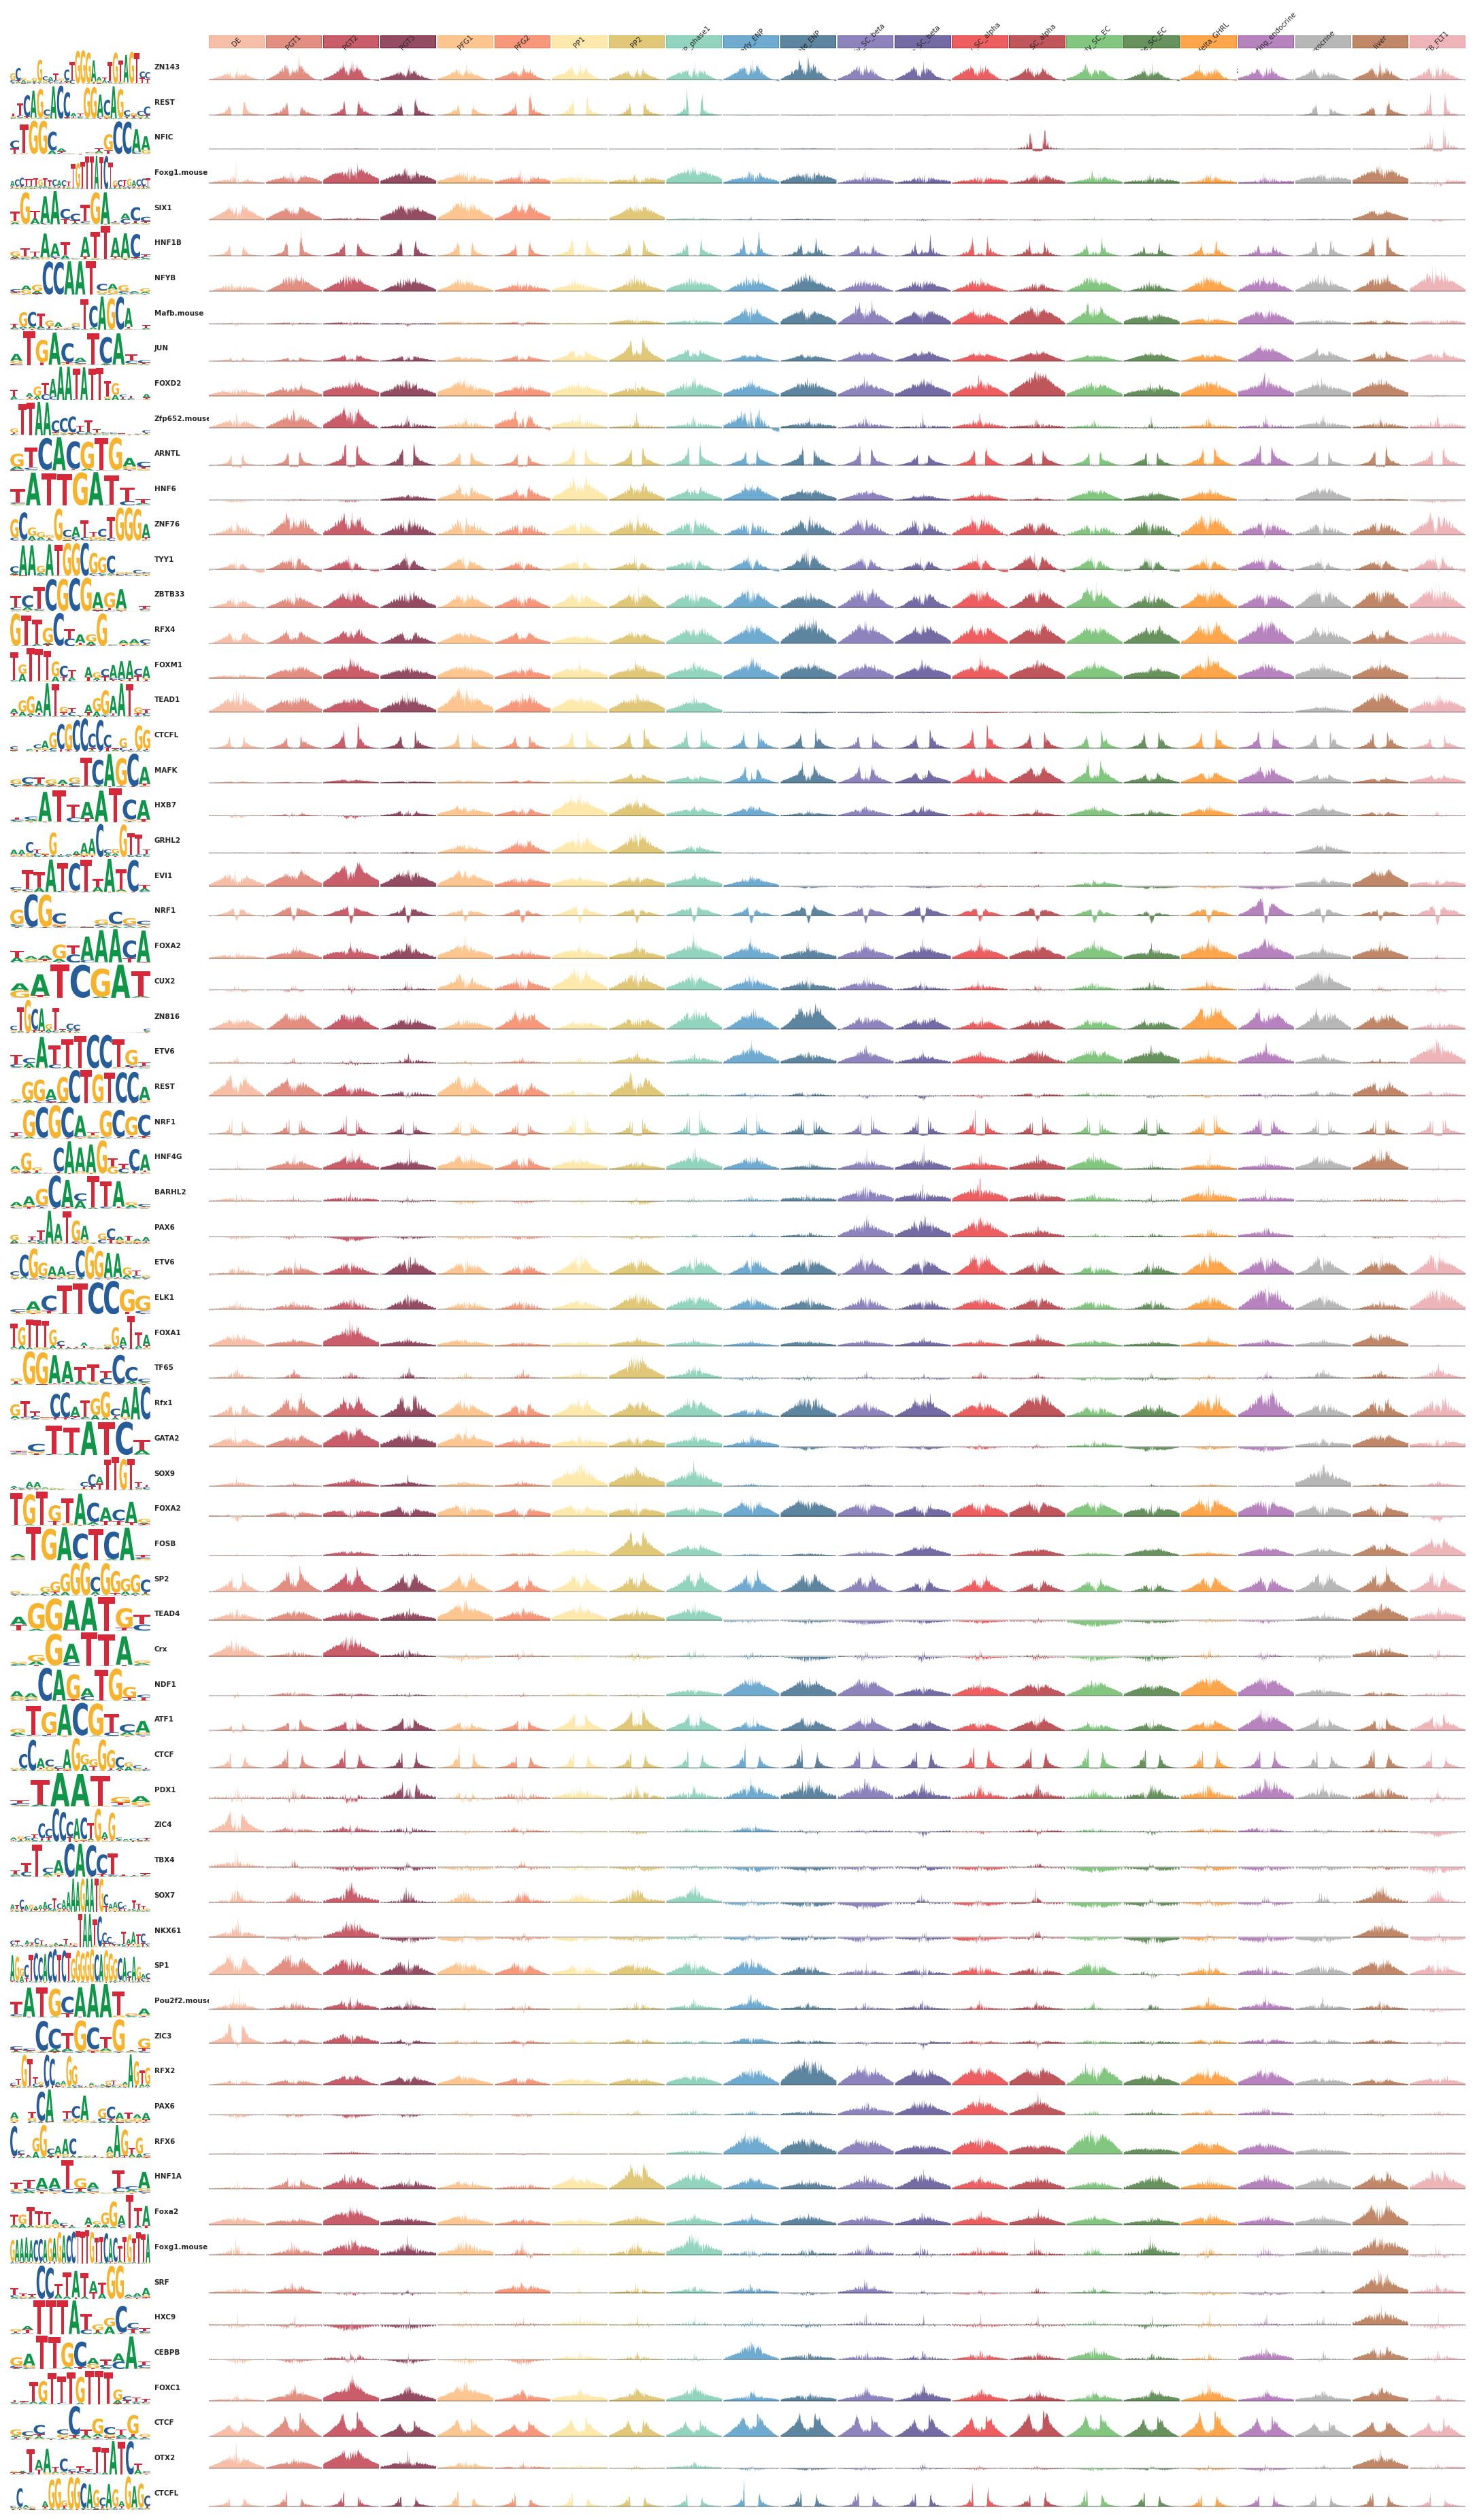

In [14]:
# Giant grid: all 70 motifs x 22 cell types, with logos
LOGO_ALPHABET = 'ACGT'
LOGO_COLORS = {"A": '#109648', "C": '#255C99', "G": '#F7B32B', "T": '#D62839'}

n_motifs = len(names)
n_models = len(ordered_models)

fig = plt.figure(figsize=(n_models * 0.7 + 3, n_motifs * 0.45), dpi=150)

# GridSpec: logo column + annotation column + profile columns, header row on top
gs = gridspec.GridSpec(
    n_motifs + 1, n_models + 2,
    width_ratios=[2.5, 1.0] + [1] * n_models,
    height_ratios=[0.4] + [1] * n_motifs,
    wspace=0.02, hspace=0.05,
)

# Column headers
ax_corner1 = fig.add_subplot(gs[0, 0])
ax_corner1.axis('off')
ax_corner2 = fig.add_subplot(gs[0, 1])
ax_corner2.axis('off')

for j, ct in enumerate(ordered_models):
    ax = fig.add_subplot(gs[0, j + 2])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=color_dict.get(ct, '#999999'), alpha=0.7))
    ax.text(0.5, 0.5, ct, ha='center', va='center', fontsize=5, rotation=45)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# Plot each motif row
for i, motif_name in enumerate(names):
    annotation = annotation_dict.get(motif_name, motif_name).split('_')[0]

    # Logo column
    ax_logo = fig.add_subplot(gs[i + 1, 0])
    ppm = motif_dict[motif_name].numpy().T
    lm_df = lm.transform_matrix(
        df=pd.DataFrame(ppm, columns=list(LOGO_ALPHABET)),
        from_type='probability',
        to_type='information',
    )
    lm.Logo(
        lm_df,
        ax=ax_logo,
        color_scheme=LOGO_COLORS,
        fade_below=0.1,
    )
    ax_logo.set_xticks([])
    ax_logo.set_yticks([])
    ax_logo.set_ylabel('')
    for spine in ax_logo.spines.values():
        spine.set_visible(False)

    # Annotation label column
    ax_label = fig.add_subplot(gs[i + 1, 1])
    ax_label.text(0.05, 0.5, annotation, ha='left', va='center', fontsize=5, fontweight='bold')
    ax_label.set_xlim(0, 1)
    ax_label.set_xticks([])
    ax_label.set_yticks([])
    for spine in ax_label.spines.values():
        spine.set_visible(False)

    # Profile columns
    motif_profiles = {ct: profiles[ct][motif_name][400:600] for ct in ordered_models}
    ymin = min(p.min() for p in motif_profiles.values())
    ymax = max(p.max() for p in motif_profiles.values())
    margin = max(abs(ymin), abs(ymax)) * 0.1
    ymin = ymin - margin
    ymax = ymax + margin

    for j, ct in enumerate(ordered_models):
        ax = fig.add_subplot(gs[i + 1, j + 2])
        color = color_dict.get(ct, '#999999')
        ax.fill_between(range(200), motif_profiles[ct], alpha=0.7, color=color, linewidth=0)
        ax.axhline(y=0, color='black', linewidth=0.2)
        ax.set_ylim(ymin, ymax)
        ax.set_xlim(0, 200)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

plt.savefig(f"{path_out}/marginalization_full_grid.pdf", dpi=150, bbox_inches="tight")
print(f"Saved full grid with logos: {n_motifs} motifs x {n_models} cell types")
plt.show()

# Per-motif row exports

Save each motif as a separate PDF showing its profile across all 22 cell types.

In [15]:
# Per-motif row exports with logo
LOGO_ALPHABET = 'ACGT'
LOGO_COLORS = {"A": '#109648', "C": '#255C99', "G": '#F7B32B', "T": '#D62839'}

per_motif_dir = f"{path_out}/per_motif"
os.makedirs(per_motif_dir, exist_ok=True)

for motif_name in names:
    annotation = annotation_dict.get(motif_name, motif_name).split('_')[0]
    motif_profiles = {ct: profiles[ct][motif_name][400:600] for ct in ordered_models}

    ymin = min(p.min() for p in motif_profiles.values())
    ymax = max(p.max() for p in motif_profiles.values())
    margin = max(abs(ymin), abs(ymax)) * 0.1
    ymin = ymin - margin
    ymax = ymax + margin

    # Logo + annotation + profiles
    fig = plt.figure(figsize=(n_models * 0.8 + 4, 1.5), dpi=150)
    gs_row = gridspec.GridSpec(1, n_models + 2, width_ratios=[3, 1.2] + [1] * n_models, wspace=0.03)

    # Logo
    ax_logo = fig.add_subplot(gs_row[0, 0])
    ppm = motif_dict[motif_name].numpy().T
    lm_df = lm.transform_matrix(
        df=pd.DataFrame(ppm, columns=list(LOGO_ALPHABET)),
        from_type='probability',
        to_type='information',
    )
    lm.Logo(lm_df, ax=ax_logo, color_scheme=LOGO_COLORS, fade_below=0.1)
    ax_logo.set_xticks([])
    ax_logo.set_yticks([])
    ax_logo.set_ylabel('')
    for spine in ax_logo.spines.values():
        spine.set_visible(False)

    # Annotation label
    ax_label = fig.add_subplot(gs_row[0, 1])
    ax_label.text(0.05, 0.5, f"{annotation}\n({motif_name})", ha='left', va='center', fontsize=7, fontweight='bold')
    ax_label.set_xlim(0, 1)
    ax_label.set_xticks([])
    ax_label.set_yticks([])
    for spine in ax_label.spines.values():
        spine.set_visible(False)

    # Profiles
    for j, ct in enumerate(ordered_models):
        ax = fig.add_subplot(gs_row[0, j + 2])
        color = color_dict.get(ct, '#999999')
        ax.fill_between(range(200), motif_profiles[ct], alpha=0.7, color=color, linewidth=0)
        ax.axhline(y=0, color='black', linewidth=0.3)
        ax.set_ylim(ymin, ymax)
        ax.set_xlim(0, 200)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_title(ct, fontsize=5, rotation=45, ha='left')

    plt.savefig(f"{per_motif_dir}/{motif_name}_{annotation}.pdf", dpi=150, bbox_inches="tight")
    plt.close(fig)

print(f"Saved {len(names)} per-motif PDFs with logos to {per_motif_dir}")

Saved 70 per-motif PDFs with logos to /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/3_single_task_models/motifs/analysis/per_motif
